In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv('drawndata1.csv')
df

,x,y,z
0,58.080365,225.699042,a
1,238.867357,247.456645,a
2,156.218212,286.588782,a
3,262.004361,284.251445,a
4,185.243183,308.187571,a
...,...,...,...
247,186.111898,41.435729,a
248,53.758007,1.473481,a
249,45.915907,23.502998,a
250,110.652516,12.141801,a


In [37]:
X = df[['x', 'y']].values
y = df['z'] = "a"

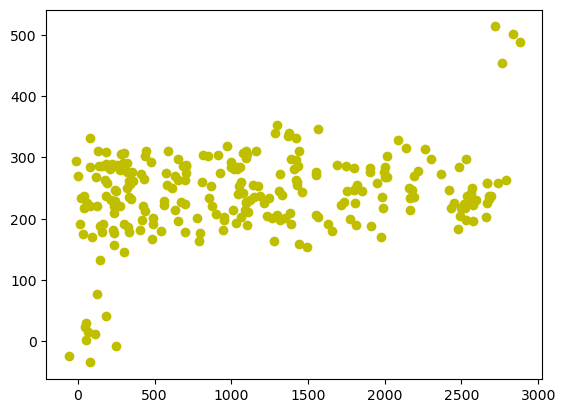

In [38]:
plt.scatter(X[:, 0], X[:, 1], c="y")

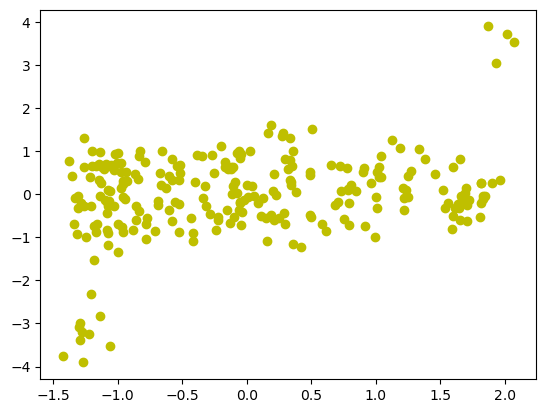

In [39]:
from sklearn.preprocessing import StandardScaler
X_new = StandardScaler().fit_transform(X)
plt.scatter(X_new[:, 0], X_new[:, 1], c="y")

(array([ 57., 178., 162., 125.,  98.,  84.,  67.,  49.,  38.,  24.,  22.,
         18.,  21.,  19.,  13.,   7.,   1.,   4.,   4.,   0.,   1.,   1.,
          1.,   0.,   2.,   1.,   0.,   0.,   1.,   2.]),
 array([-1.21916908, -0.97788169, -0.73659429, -0.4953069 , -0.2540195 ,
        -0.01273211,  0.22855529,  0.46984268,  0.71113008,  0.95241747,
         1.19370487,  1.43499226,  1.67627965,  1.91756705,  2.15885444,
         2.40014184,  2.64142923,  2.88271663,  3.12400402,  3.36529142,
         3.60657881,  3.84786621,  4.0891536 ,  4.330441  ,  4.57172839,
         4.81301579,  5.05430318,  5.29559058,  5.53687797,  5.77816537,
         6.01945276]),
 <BarContainer object of 30 artists>)

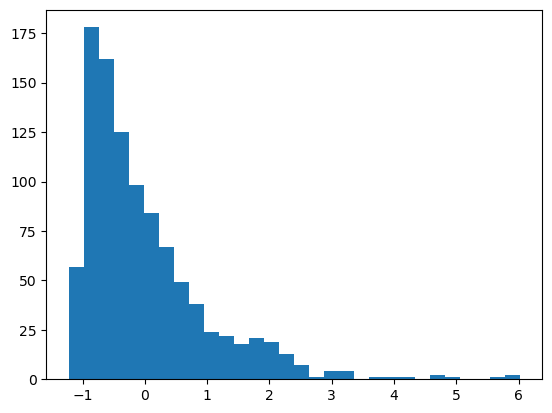

In [40]:
x = np.random.exponential(10, (1000)) + np.random.normal(0, 1, (1000))
plt.hist((x - np.mean(x))/np.std(x), 30)

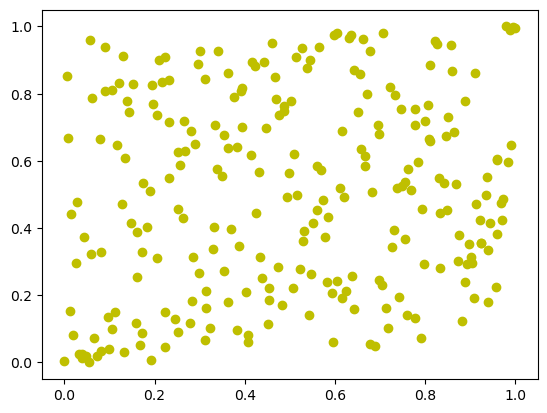

In [41]:
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline 

X_new = QuantileTransformer(n_quantiles=100).fit_transform(X)
plt.scatter(X_new[:, 0], X_new[:, 1], c='y');

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# Load data
df = pd.read_csv("drawndata1.csv")
X = df[['x', 'y']].values
y = (df['z'] == "a").astype(int) 
def plot_output(scaler):
    pipe = Pipeline([
        ("scale", scaler),
        ("model", KNeighborsClassifier(n_neighbors=20, weights='distance'))
    ])
    
    # ✅ Fit model (this also fits the scaler internally)
    pred = pipe.fit(X, y).predict(X)

    # Plot original data
    plt.figure(figsize=(9, 3))
    plt.subplot(131)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
    plt.title("Original Data")

    # ✅ Use pipe['scale'] to access the fitted scaler
    X_tfm = pipe['scale'].transform(X)
    plt.subplot(132)
    plt.scatter(X_tfm[:, 0], X_tfm[:, 1], c=y, cmap='coolwarm')
    plt.title("Transformed Data")

    # Generate random new data
    X_new = np.concatenate([
        np.random.uniform(0, X[:, 0].max(), (5000, 1)), 
        np.random.uniform(0, X[:, 1].max(), (5000, 1))
    ], axis=1)

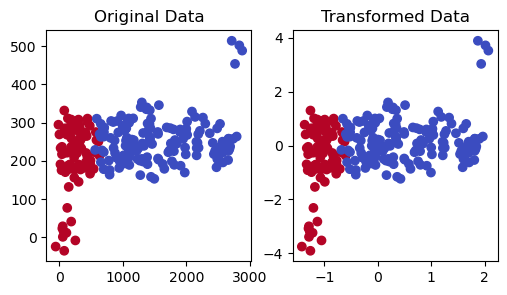

In [47]:
plot_output(scaler=StandardScaler())

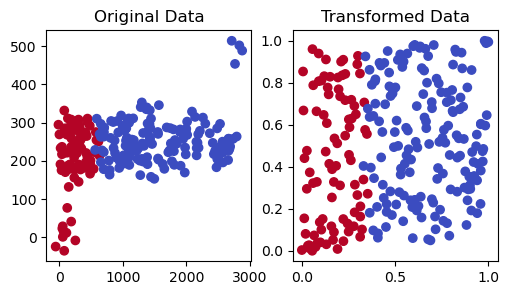

In [48]:
plot_output(scaler=QuantileTransformer(n_quantiles=100))

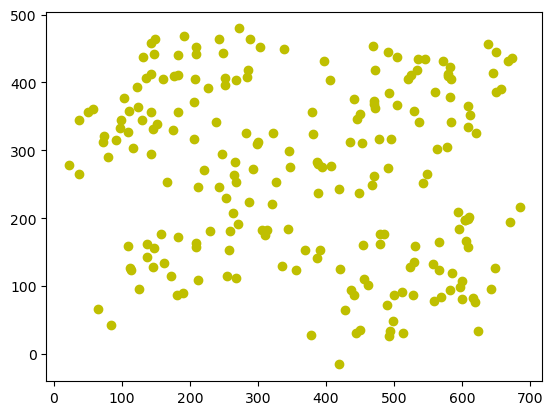

In [49]:
df2 = pd.read_csv('drawndata2.csv')
X_2 = df2[['x', 'y']].values
y_2 = df2['z'] == 'a'
plt.scatter(X_2[:,0], X_2[:,1], c='y')